In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import flood


In [2]:
def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

>**3. (*) Umbralización híbrida (combinación de Otsu + morfología). ¿Cómo mejorar la segmentación
de objetos con ruido o regiones conectadas? Práctica sugerida: Aplicar Otsu, luego refinar con
cv2.morphologyEx() (apertura o cierre).**


En este ejercicio se observa cómo luego de aplicar Otsu para la binarización de la imagen del paisaje por ejemplo, si se quisiera segmentar para diferenciar el lago, aplicando apertura se unen los huecos permitiendo distinguir lo demás como una sola región.  
Para el ejemplo del círculo, si consideramos los circulos interiores como ruido, observamos que con una clausura se une toda la región.

In [4]:
def show_images(images, titles=None):
    """Display multiple images in a grid."""
    n = len(images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

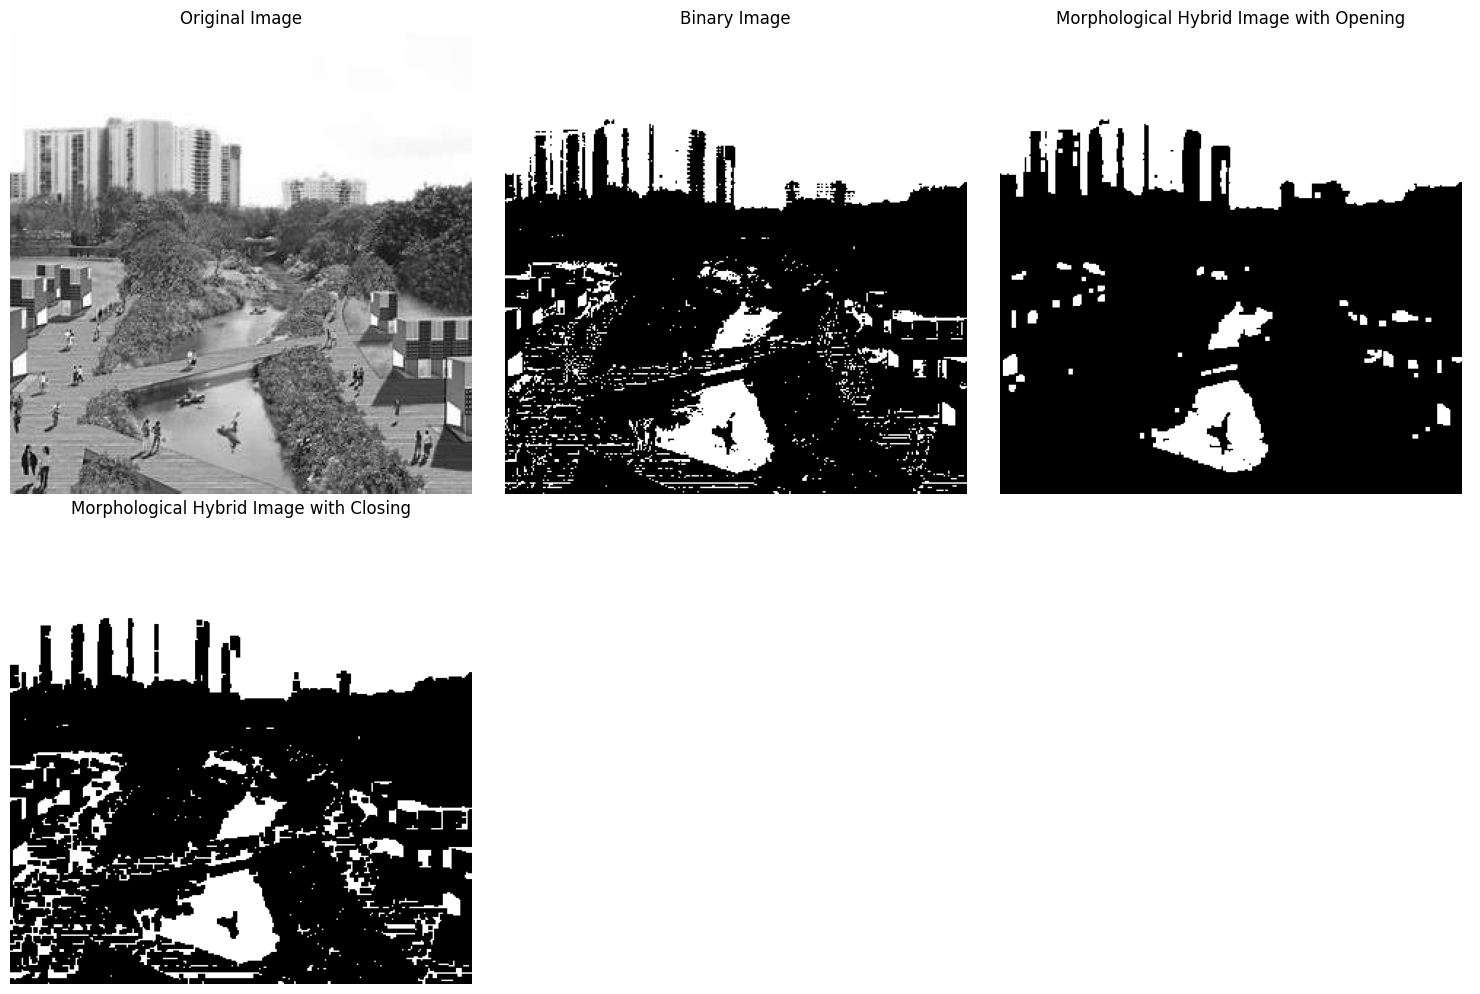

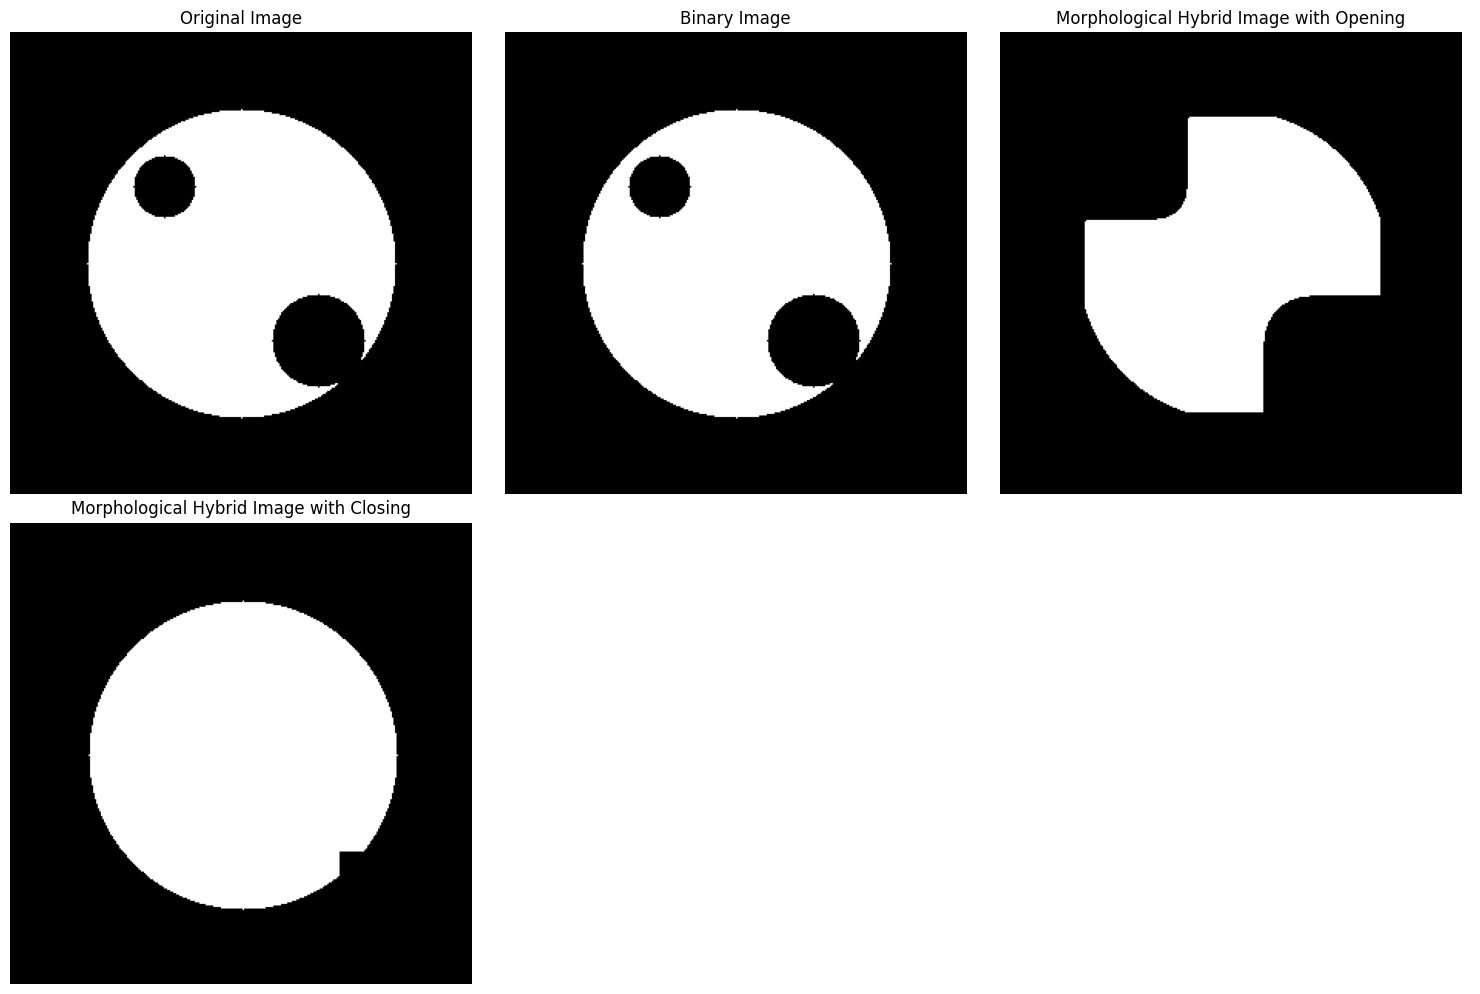

In [ ]:
def ej_3(img,kernel_size=3):
    _, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((kernel_size,kernel_size), np.uint8)
    cierre = cv2.morphologyEx(img_otsu, cv2.MORPH_CLOSE, kernel)
    apertura = cv2.morphologyEx(img_otsu, cv2.MORPH_OPEN, kernel)
    return img_otsu, cierre, apertura

img1 = cv2.imread('images/paisaje1.jpg', cv2.IMREAD_GRAYSCALE)
binaria, new_img_cierre, new_img_apertura = ej_3(img1)

imagenes = [
    img1,
    binaria,
    new_img_apertura,
    new_img_cierre
]
titulos = [
    'Original Image',
    'Binary Image',
    'Morphological Hybrid Image with Opening',
    'Morphological Hybrid Image with Closing'
]
show_images(imagenes, titulos)



img2 = cv2.imread('images/img_binaria2.png', cv2.IMREAD_GRAYSCALE)
binaria, new_img_cierre, new_img_apertura = ej_3(img2, kernel_size=50)

imagenes = [
    img2,
    binaria,
    new_img_apertura,
    new_img_cierre]
titulos = [
    'Original Image',
    'Binary Image',
    'Morphological Hybrid Image with Opening',
    'Morphological Hybrid Image with Closing'
]
show_images(imagenes, titulos)







>**4. (*) Segmentación por detección de bordes. ¿Cómo se puede usar la información de bordes para
segmentar una imagen? Práctica sugerida: Detectar bordes con cv2.Canny() o skimage.filters.sobel,
luego aplicar umbral y cerrar regiones con morfología.**

La información de bordes es fundamental para la segmentación de imágenes, ya que los bordes suelen marcar las fronteras naturales entre objetos o regiones con diferentes propiedades visuales, como intensidad, color o textura.

Cuando se detectan los bordes en una imagen, por ejemplo usando el algoritmo de Canny, se obtiene una representación binaria donde los píxeles que forman parte de un borde tienen un valor alto (generalmente 255) y el resto son cero. Esta imagen de bordes no segmenta por sí sola, pero puede guiar o asistir a los algoritmos de segmentación, aportando información estructural clave.

Una forma de utilizar esta información es como entrada para métodos como Watershed, donde los bordes pueden actuar como barreras que impiden la fusión de regiones durante la expansión del algoritmo. También pueden servir como base para generar máscaras o semillas que indiquen con más precisión dónde se encuentran los objetos de interés y sus límites.  

En el ejercicio se aplicó Canny para la obtención de bordes para luego aplicar clausura, uniendo las regiones y consiguiendo aproximar una máscara para segmentación.

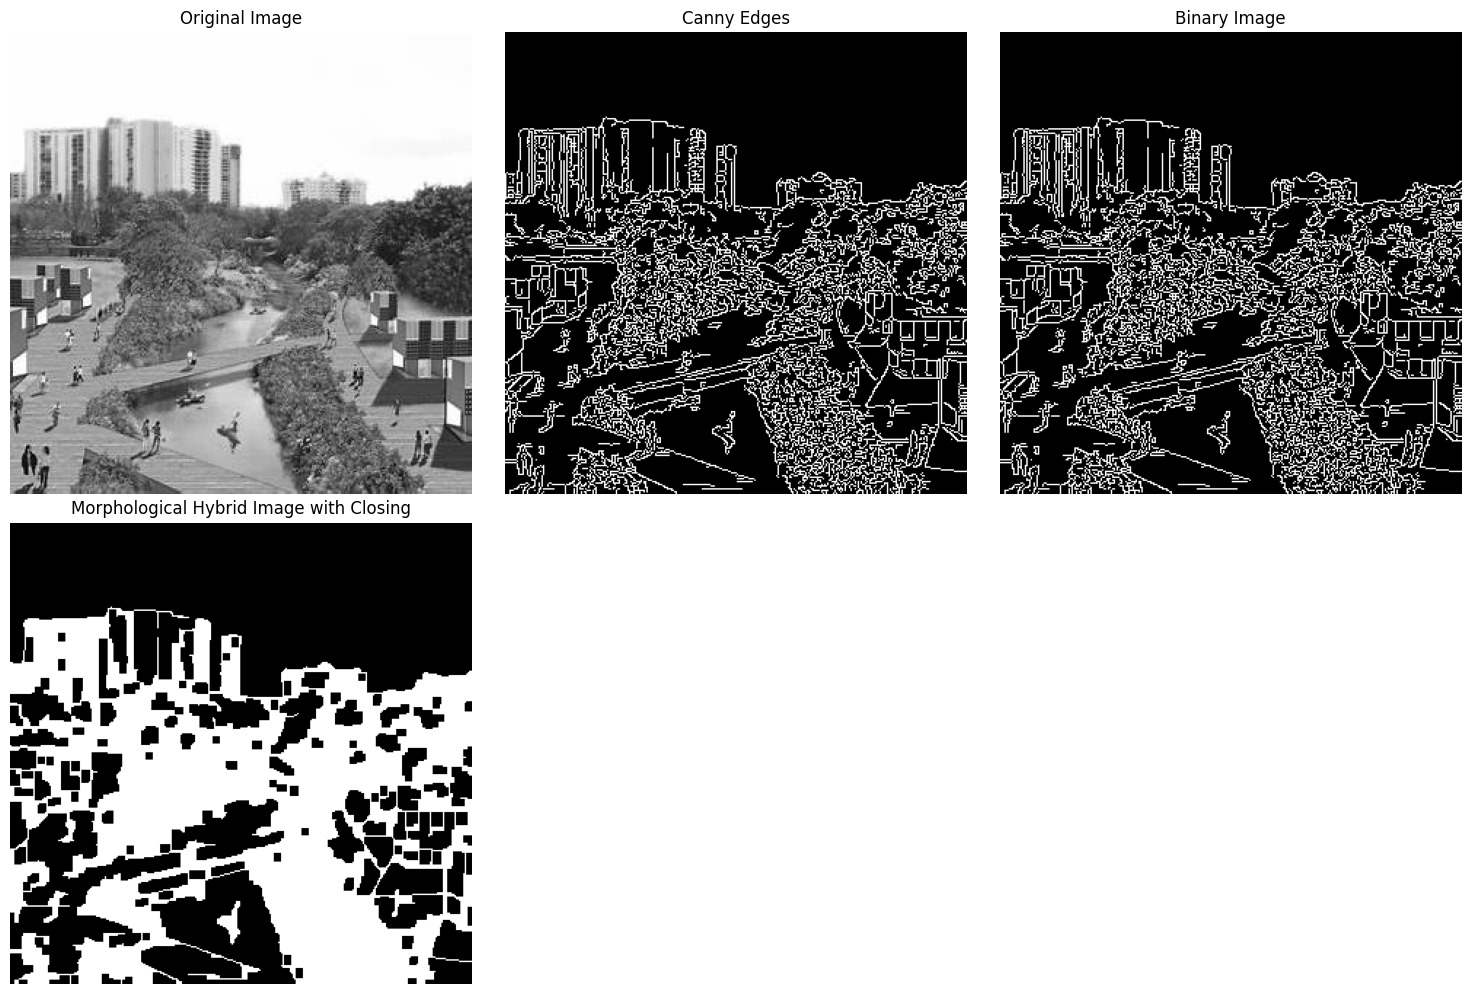

In [51]:
def ej_4(img,kernel_size=5):
    bordes = cv2.Canny(img, 100, 200)
    _, img_otsu = cv2.threshold(bordes, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((kernel_size,kernel_size), np.uint8)

    cierre = cv2.morphologyEx(img_otsu, cv2.MORPH_CLOSE, kernel)
    
    return bordes,img_otsu, cierre

img1 = cv2.imread('images/paisaje1.jpg', cv2.IMREAD_GRAYSCALE)
bordes, binaria, new_img_cierre = ej_4(img1)

imagenes = [
    img1,
    bordes,
    binaria,
    new_img_cierre
]
titulos = [
    'Original Image',
    'Canny Edges',
    'Binary Image',
    'Morphological Hybrid Image with Closing'
]
show_images(imagenes, titulos)

**8. (*) Segmentación basada en regiones (crecimiento o split-merge). ¿Cómo se puede segmentar una
imagen expandiendo regiones homogéneas? Práctica sugerida: Usar skimage.segmentation.flood() o
flood fill() para realizar crecimiento de regiones desde semillas.**

Una imagen se puede segmentar de esta manera partiendo de un punto o semilla en la imágen dentro del objeto a segmentar, el algoritmo se encarga de ir recorriendo los pixeles adyacentes y clasificarlos como parte del objeto siempre que sean similares a los anteriores y hasta llegar a algún pixel que se encuentre fuera del objeto, en este momento seguirá un camino distinto hasta haber encontrado todos los pixeles pertenecientes a este.  
Para este ejericico se utilizó `skimage.segmentation.flood()` que retorna una matriz booleana del tamaño de la imagen original con 0 (ceros) representando el fondo y 1  (unos) los objetos iguales o similares.

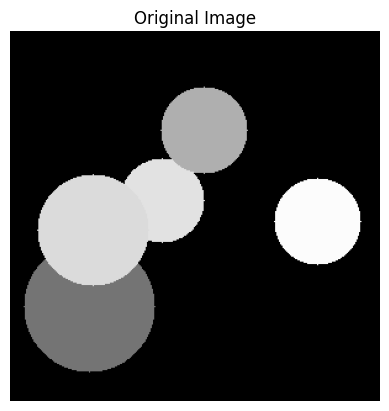

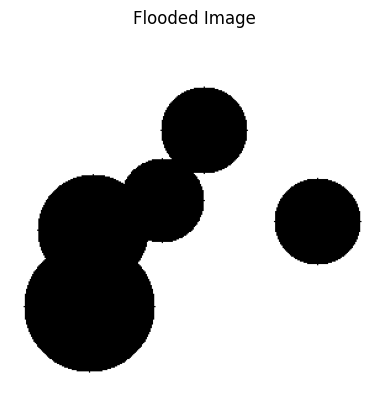

In [16]:
def ej8(img):
    # Image size
    h, w = img.shape[:2]
    return flood(img, (round(50),round(50)), tolerance=0.05)

original_image = cv2.imread('images/img_grises2.png', cv2.IMREAD_GRAYSCALE)
flooded_image = ej8(original_image)
show_image(original_image, 'Original Image')

plt.imshow(flooded_image, cmap='gray')
plt.title('Flooded Image')
plt.axis('off')
plt.show()



**10. (*) Segmentación por combinación de técnicas (pipeline) Pregunta: ¿Qué beneficios tiene combinar
varias técnicas de segmentación en un mismo flujo de procesamiento? Práctica sugerida: Aplicar
primero Canny + morfología para generar una máscara, luego segmentar con Watershed o K-means
sobre la región recortada.**

El beneficio se encuentra en que cada técnica aporta distintas ventajas para poder realizar la segmentación. En el ejemplo de este ejercicio, por un lado Canny detecta contornos de forma nítida y precisa, luego las técnicas de morfología permiten suavizar la imagen (si fuera necesario) y rellenar las regiones para finalmente poder realizar la segmentación aplicando el algoritmo de Watershed.  
Para el algoritmo de Watershed se hicieron algunos procesamientos previos para obtener la información necesaria:  
- Transformada de distancia: Sirve para detectar regiones "seguras" del primer plano: los puntos más internos de los objetos, que seguro pertenecen a un solo objeto. Esto a grandes razgos crea un "mapa de calor" indicando en cada píxel cuan lejos está del fondo o el exterior del objeto a segmentar.  
- Región segura del fondo: Aumenta las áreas negras de la imagen con `cv2.dilate` (que corresponden al fondo). Así se obtiene una región del fondo que sabemos con certeza que es fondo.  
- Región desconocida: Resta el primer plano del fondo para obtener una zona de incertidumbre donde no se está seguro si pertenece al fondo o a algún objeto.
- Etiquetado de marcadores: `connectedComponents` da un número distinto a cada región de primer plano segura. Se le suma 1 para que el fondo tenga el valor 1 (y no 0).Se marca la zona desconocida con 0, que es lo que necesita cv2.watershed() para saber qué zonas tiene que decidir a cuál marcador pertenecen.


Markers unique values: [0 2 3 4 5 6]


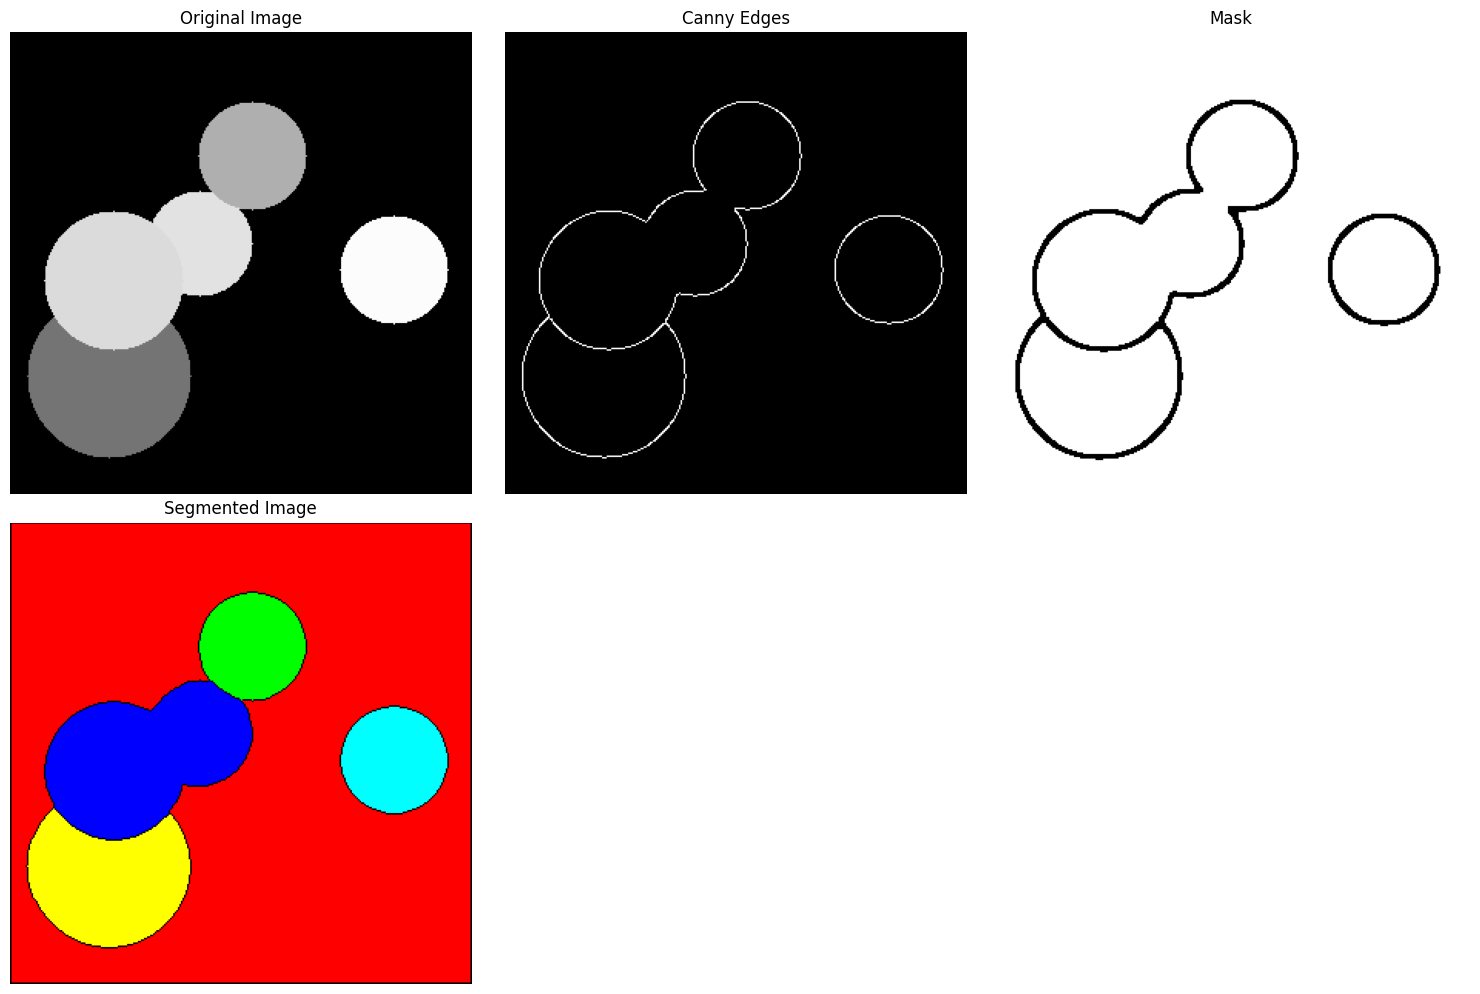

In [45]:
def ej10(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Canny edge detection
    edges = cv2.Canny(gray, 150, 500)

    # Rellenar objetos: morfología de cierre + dilatación
    kernel = np.ones((3, 3), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)
    dilated = cv2.dilate(closed, kernel, iterations=1)

    kernel = np.ones((5, 5), np.uint8)


    # Invertir para que los objetos sean blancos
    mask = cv2.bitwise_not(dilated)
    #mask = dilated

    # Transformada de distancia para encontrar objetos (región segura)
    dist_transform = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    # Región segura del fondo
    sure_bg = cv2.dilate(mask, kernel, iterations=3)

    # Región desconocida
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Etiquetado de marcadores
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    print("Markers unique values:", np.unique(markers))

    # Watershed
    markers = cv2.watershed(img, markers)

    
    # Crear una imagen de salida coloreada
    segmented = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
    colors = [(0,0,255), (0,255,0), (255,0,0), (255,255,0), (0,255,255), (255,0,255), (128,128,0), (128,0,128), (0,128,128)]

    for label in np.unique(markers):
        if label == -1:
            segmented[markers == label] = [0, 0, 0]  # borde
        elif label == 1:
            segmented[markers == label] = [128, 128, 128]  # fondo (opcionalmente distinto)
        else:
            segmented[markers == label] = colors[(label - 2) % len(colors)]

    # Mostrar resultados
    show_images([img, edges, mask, segmented], 
                titles=['Original Image', 'Canny Edges', 'Mask', 'Segmented Image'])
    

    
    
img = cv2.imread('images/img_grises2.png')
ej10(img)

**11. (*) Elegir y describir alguna de las siguientes tecnicas de segmentación:  
(a) Basada en Clustering  
(b) Basada en Grafos  
(c) Basadas en Modelos Probabilísticos y Estadísticas** 

**Segmentación basada en Grafos**  
La segmentación basada en grafos es un enfoque que modela una imagen como un grafo, donde cada píxel (o superpíxel) representa un nodo y las conexiones entre estos nodos, llamadas aristas, reflejan relaciones de similitud entre los píxeles, como la diferencia de color, textura o intensidad. La idea central es dividir la imagen en regiones que sean internamente coherentes y externamente distintas, utilizando propiedades del grafo.

En este contexto, el algoritmo más conocido es el de Felzenszwalb y Huttenlocher, que construye una jerarquía de regiones conectadas a partir de un análisis de las diferencias entre los nodos conectados. Se define una medida de disimilitud entre regiones, y se van agrupando aquellas cuya diferencia interna es menor que un umbral dinámico. Esto permite una segmentación eficiente y rápida que se adapta automáticamente a la estructura de la imagen, sin necesidad de parámetros globales como el número de regiones a extraer.

Este enfoque tiene ventajas como su velocidad y su capacidad de manejar bien imágenes con ruido o estructuras complejas. Además, al trabajar con superpíxeles o regiones en lugar de píxeles individuales, puede mantener bordes nítidos y producir segmentaciones con significado semántico más alto.

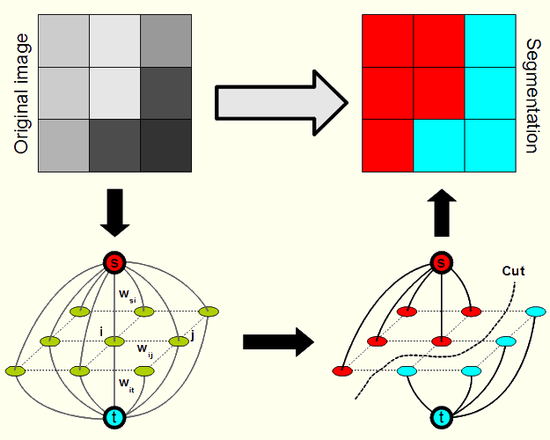